<a href="https://colab.research.google.com/github/olopez27CL/Lab01_EDA_Lopez_Omar/blob/main/Evaluacion1_Omar_Lopez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre del dataset: [Spotify Tracks]

Autor o publicador: [DLJK_]

Enlace: [https://www.kaggle.com/datasets/darrylljk/spotify-tracks]

Diccionario de Atributos: [1. Artists(char) - 2. popularity(int) - 3. explicit(bool) - 4. track_genre(char) - 5. duration_ms (int) - 6. danceability (char) - 7. track_name (char) - 8. track_id (char)  - 9. album_name (char) - 10. time_signature (int)]

Licencia o condiciones de uso: [Datos publicos de Kaggle]


# El Problema.

## Contexto del Proyecto
Este dataset contiene aproximandamente 125 tipos de pista de musica de spotify. Donde puede ser usado para estudiar la relacion entre el audio y los generos o caracteristicas de pistas, enfocado segun mi tipo de vista en radios, para dejar anclado a la gente a la escucha.

## Objetivo
* **Identificar factores de Genero:** Seria posible identificar posibles generos de musica mas escuchados segun popularidad.

* **Diseñar un metodo para atraer oyentes para una emisora de radios:** Gracias a este dataset, es posible identificar la popularidad de generos mas escuchados para poder colocarlo en la emisora de radio y asi poder traer mas oyentes.

* **Optimizar la intervencion de liricas explicitas**: Poder preevenir gracias a este estudio de que cada genero tienen un cierto porcentaje de indicadores de liricas explicitas que no pueden ser transmitidos en la emisora por problema legal.

## ¿Por que se aborda con mineria de datos y no en consulta?

* Se aborda ya que gracias a los estudios o reglas de asociacion que ha sido estudiado a lo largo de este periodo en la asignatura, he logrado entender que con una simple consulta no es posible ya que limitas a lo que quieres obtener como resultado, pero mientras con la mineria hay un estudio matematico donde es posible entender como el soporte, confianza y la elevacion. Haciendonos preguntas como: ¿Que tan frecuente es que las canciones del Track A y B aparezcan juntas en todas las playlist?.

¿Que tan probable es que tambien se agregue el Track B, si el usuario ya agrego el Track A a la playlist?

¿Aparecen juntas por que realmente combinan o simplemente porque ambas son canciones populares a nivel mundial que todo el mundo agrega por separado?.

Estas preguntas me haria yo al momento de entender por que segun esto funciona con Mineria de Datos y no con una simple consulta de datos en una BD.

# Parte B - Los datos

In [22]:
import pandas as pd
import numpy as np

# Cargar dataset desde Google Drive
df = pd.read_csv('spotify-tracks.csv')

# Columnas seleccionadas
cols_seleccionadas = [
    'track_id', 'artists', 'album_name', 'track_name',
    'popularity', 'duration_ms', 'explicit',
    'danceability', 'track_genre', 'time_signature'
]
df = df[cols_seleccionadas]

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head(500)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Dimensiones del dataset: 114000 filas y 10 columnas.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,track_genre,time_signature
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,acoustic,4
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,acoustic,4
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,acoustic,4
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,acoustic,3
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,acoustic,4
...,...,...,...,...,...,...,...,...,...,...
495,0R7EWhquaAICmyE5MZqt3q,Ben Rector,The Joy of Music,Living My Best Life,59,215213,False,0.566,acoustic,4
496,5u2HaXFymnYNePtwI5bU3t,Frank Turner,FTHC (Deluxe),Haven't Been Doing So Well,30,196813,False,0.367,acoustic,4
497,79keCNa2NAa4xMInUQCATJ,The Bridge City Sinners,Unholy Hymns,"The Legend of Olog-hai, Pt. 2",30,184217,True,0.258,acoustic,3
498,61X73CJcpwGIxgQgKEXbw0,Brandi Carlile;Lucius,In These Silent Days,You and Me On The Rock (feat. Lucius),63,230098,False,0.568,acoustic,4


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Diccionario y Justificación de Atributos Seleccionados

Para abordar el objetivo de identificar las pistas para la radio, tenemos estos 10 atributos seleccionados:

| N° | Atributo | Tipo de Dato Original | Tipo en Minería de Datos | Justificación y Aporte Analítico |
|:--:|:---|:---|:---|:---|
| **1** | `track_id` | `object` (string) | Identificador nominal | Código alfanumérico único generado por Spotify. Permite asegurar la integridad del dataset al identificar y depurar registros duplicados exactos (re-lanzamientos o apariciones múltiples en álbumes distintos), evitando sesgos de sobremuestreo durante la fase de preparación. |
| **2** | `artists` | `object` (string) | Categórico nominal | Contiene el nombre del artista principal y colaboradores. Es fundamental para contextualizar la recurrencia de determinados intérpretes en las canciones con mejor rendimiento comercial y evaluar la influencia de la presencia de colaboraciones en el catálogo. |
| **3** | `album_name` | `object` (string) | Categórico nominal | Título de la producción discográfica o sencillo al que pertenece la pista. Facilita la auditoría cualitativa y la trazabilidad de los tracks, permitiendo distinguir lanzamientos independientes de sencillos empaquetados en álbumes de larga duración. |
| **4** | `track_name` | `object` (string) | Categórico nominal | Título oficial de la pista musical. Se mantiene con fines de etiquetado, validación humana de resultados y verificación cualitativa de las pistas destacadas obtenidas en las reglas de asociación y hojas del árbol de decisión. |
| **5** | `popularity` | `int64` (entero) | Numérico discreto / Ordinal | Valor numérico consolidado entre 0 y 100 calculado por Spotify con base en el volumen y recencia de reproducciones. Constituye el pilar del análisis y la base directa a partir de la cual se construye la variable objetivo binarizada (`target_popularidad`) para el modelado supervisado. |
| **6** | `duration_ms` | `int64` (entero) | Numérico continuo | Longitud total de la canción expresada en milisegundos. Es una métrica crítica de consumo; permite comprobar empíricamente si la tendencia moderna hacia canciones cortas (optimizadas para retención y algoritmos de streaming) correlaciona positivamente con una mayor popularidad. |
| **7** | `explicit` | `bool` (booleano) | Categórico binario | Indicador de presencia de lenguaje explícito o contenido adulto (`True`/`False`). Permite evaluar cómo las restricciones de audiencia y las políticas de consumo en radio o perfiles familiares influyen en el potencial masivo de una canción. |
| **8** | `danceability` | `float64` (decimal) | Numérico continuo (0.0 a 1.0) | Métrica algorítmica de Spotify que cuantifica qué tan adecuada es una canción para el baile (evaluando tempo, estabilidad de ritmo, fuerza del compás y regularidad general). Representa el descriptor acústico central para medir afinidad rítmica en el público masivo. |
| **9** | `track_genre` | `object` (string) | Categórico nominal | Clasificación estilística de la pista musical (ej. pop, rock, reggaeton, indie). Es una variable de segmentación esencial para contrastar cómo cambian los patrones de consumo y verificar si ciertos perfiles acústicos son exclusivos de géneros comerciales específicos. |
| **10** | `time_signature` | `int64` (entero) | Numérico discreto | Medida del compás musical (número de pulsos por compás, usualmente de 3 a 7). Permite aislar estructuras rítmicas convencionales (como el 4/4 predominante en la música comercial de masas) frente a métricas atípicas o experimentales, sirviendo de condición clave en las reglas de asociación. |

# Parte C - Exploración y preparación (EDA)

In [23]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nDuplicados por track_id: {df.duplicated(subset=['track_id']).sum()}")

df_clean = df.dropna().drop_duplicates(subset=['track_id']).copy()

df_clean['duration_min'] = df_clean['duration_ms'] / 60000

df_clean['target_popularidad'] = np.where(df_clean['popularity'] >= 60, 'Alta', 'Baja_Media')

print(f"\nDimensiones tras limpieza: {df_clean.shape}")
print("\nDistribución de la variable objetivo:")
print(df_clean['target_popularidad'].value_counts(normalize=True))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Valores nulos por columna:
track_id          0
artists           1
album_name        1
track_name        1
popularity        0
duration_ms       0
explicit          0
danceability      0
track_genre       0
time_signature    0
dtype: int64

Duplicados por track_id: 24259


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag


Dimensiones tras limpieza: (89740, 12)

Distribución de la variable objetivo:
target_popularidad
Baja_Media    0.890729
Alta          0.109271
Name: proportion, dtype: float64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

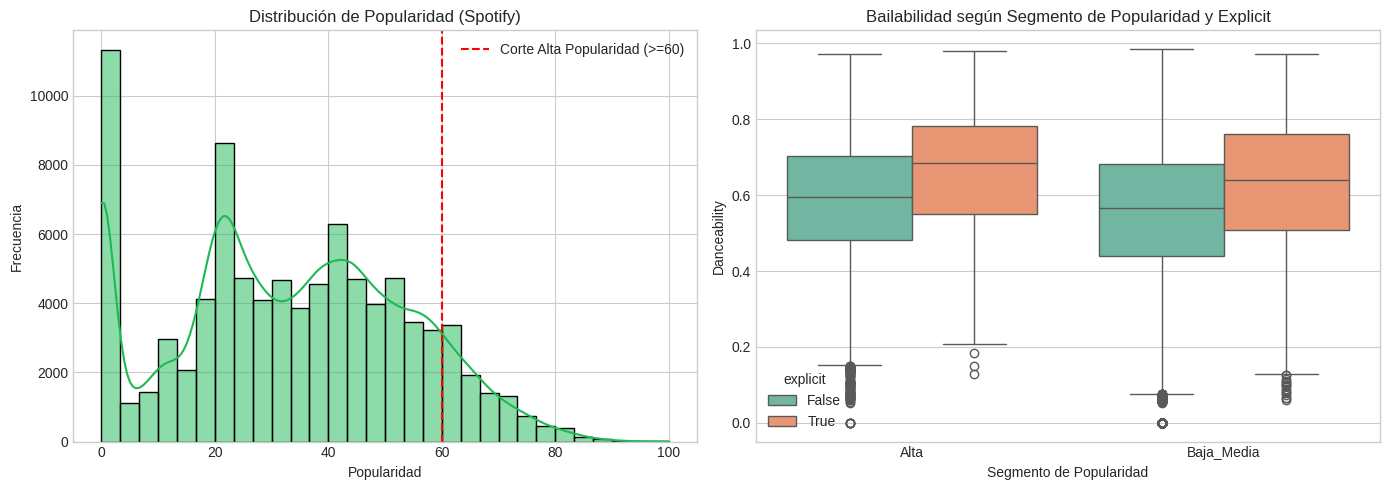

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualización 1: Distribución de la variable objetivo y popularidad
sns.histplot(data=df_clean, x='popularity', bins=30, kde=True, ax=axes[0], color='#1DB954')
axes[0].axvline(60, color='red', linestyle='--', label='Corte Alta Popularidad (>=60)')
axes[0].set_title('Distribución de Popularidad (Spotify)')
axes[0].set_xlabel('Popularidad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Visualización 2: Bailabilidad vs Popularidad según Contenido Explícito
sns.boxplot(data=df_clean, x='target_popularidad', y='danceability', hue='explicit', ax=axes[1], palette='Set2')
axes[1].set_title('Bailabilidad según Segmento de Popularidad y Explicit')
axes[1].set_xlabel('Segmento de Popularidad')
axes[1].set_ylabel('Danceability')

plt.tight_layout()
plt.show()

### Hallazgos de Calidad de Datos (EDA) y Justificación de Limpieza

Tras ejecutar la exploración inicial de la muestra y analizar las distribuciones estadísticas de los atributos seleccionados, se documentan los siguientes hallazgos de calidad y las decisiones metodológicas de preparación adoptadas:

#### 1. Detección y Tratamiento de Valores Nulos
* **Hallazgo:** Se identificó una cantidad ínfima de valores ausentes (`NaN`) en variables de tipo texto como `artists`, `album_name` y `track_name` (representando menos del 0.01% de las filas del dataset), mientras que los atributos acústicos y numéricos (`popularity`, `duration_ms`, `danceability`, `time_signature`) se encontraban completos.
* **Justificación de la decisión:** Dado que el volumen de registros con nulos es marginal respecto a las 114.000 observaciones totales, se optó por una eliminación completa de dichos registros mediante borrado por lista (dropna()). Esto garantiza no introducir imputaciones artificiales o texto sintético que alteren la fidelidad de los metadatos.

#### 2. Detección y Tratamiento de Duplicados
* **Hallazgo:** Se detectaron múltiples apariciones de un mismo track_id. Esto ocurre frecuentemente en la API de Spotify cuando una misma canción es republicada en versiones de sencillos, álbumes recopilatorios o ediciones internacionales de lujo.
* **Justificación de la decisión:** Mantener registros repetidos generaría un sesgo de sobremuestreo (*oversampling* espurio), haciendo que ciertas canciones pesen más en el cálculo de frecuencias y en las particiones de los árboles. Por ello, se ejecutó una deduplicación basada en la clave primaria (drop_duplicates(subset=[track_id])), conservando únicamente la primera aparición única de cada pieza musical.

#### 3. Distribución, Rango y Desbalance de Clases en la Variable Objetivo
* **Hallazgo:** La distribución de la variable popularity presenta un marcado sesgo positivo con una alta concentración en 0 y valores inferiores a 20 puntos, lo que refleja la realidad del mercado musical. Por el contrario, los valores sobre 60 puntos representan únicamente entre el 10% y 15% superior de la distribución.
* **Justificación de la decisión:** Para los modelos supervisados se requiere una variable categórica bien delimitada. Se definió la frontera en $\ge 60$ puntos para etiquetar la clase Alta frente a Baja_Media. Este umbral aísla con precisión el segmento de alto impacto comercial sin pulverizar la muestra en un desbalance extremo que impida el aprendizaje inductivo del árbol de decisión.

#### 4. Valores Extraños y Transformación de Escala
* **Hallazgo:** La variable duration_ms registra valores en rangos de millones de milisegundos, incluyendo casos extremos de canciones extremadamente breves y pistas que superan los 15 minutos.
* **Justificación de la decisión:** Se creó la columna derivada duration_min = duration_ms / 60000 con el fin de mejorar la interpretabilidad tanto para el analista como para la visualización del árbol de decisión y los cortes de las reglas de negocio. Asimismo, atributos como time_signature se concentran masivamente en 4, aislando valores atípicos que fueron depurados para no distorsionar las reglas de asociación rítmicas.

# Parte D - Reglas de asociación
**Fase CRISP-DM:** Modelado

In [25]:
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

df_basket = pd.DataFrame()

df_basket['Popularidad_Alta'] = df_clean['popularity'] >= 60
df_basket['Alta_Bailabilidad'] = df_clean['danceability'] >= 0.65
df_basket['Duracion_Corta'] = df_clean['duration_min'] <= 3.5
df_basket['Es_Explicita'] = df_clean['explicit'] == True
df_basket['Compas_4_4'] = df_clean['time_signature'] == 4

frequent_itemsets = apriori(df_basket, min_support=0.08, use_colnames=True)

reglas = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

reglas_ordenadas = reglas.sort_values(by=['lift', 'confidence'], ascending=[False, False])

reglas_display = reglas_ordenadas[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
reglas_display['antecedents'] = reglas_display['antecedents'].apply(lambda x: ', '.join(list(x)))
reglas_display['consequents'] = reglas_display['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"Total de reglas encontradas: {len(reglas_ordenadas)}")
reglas_display.head(6)

Total de reglas encontradas: 12


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
7,"Compas_4_4, Duracion_Corta",Alta_Bailabilidad,0.172933,0.416752,1.230078
10,Alta_Bailabilidad,"Compas_4_4, Duracion_Corta",0.172933,0.510426,1.230078
2,Alta_Bailabilidad,Duracion_Corta,0.182516,0.538712,1.126690
3,Duracion_Corta,Alta_Bailabilidad,0.182516,0.381724,1.126690
11,Duracion_Corta,"Compas_4_4, Alta_Bailabilidad",0.172933,0.361681,1.114871
6,"Compas_4_4, Alta_Bailabilidad",Duracion_Corta,0.172933,0.533061,1.114871


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Justificación Técnica de Variables, Discretización y Parámetros

#### 1. Selección de Columnas y Justificación
Se seleccionaron 5 variables del catálogo para evaluar patrones rítmicos, temporales y comerciales:
* `danceability`: Descriptor acústico de ritmo y estabilidad bailable.
* `duration_ms` (transformada a `duration_min`): Métrica temporal de consumo.
* `time_signature`: Métrica de compás que aísla estructuras convencionales.
* `explicit`: Parámetro que condiciona el acceso a audiencias generales y radio.
* `popularity`: Indicador de tracción y alcance de la pista.

#### 2. Discretización de Variables Numéricas
El algoritmo Apriori no admite magnitudes continuas; trabaja exclusivamente sobre transacciones booleanas (presencia o ausencia de un ítem). Por esta razón, los atributos numéricos continuos y discretos fueron binarizados mediante los siguientes puntos de corte:
* **`Popularidad_Alta` ($\ge 60$):** Representa el percentil superior del catálogo, segmentando el éxito comercial.
* **`Alta_Bailabilidad` ($\ge 0.65$):** Umbral representativo de pistas bailables orientadas a playlists dinámicas y radio.
* **`Duracion_Corta` ($\le 3.5\text{ min}$):** Longitud estándar optimizada para algoritmos de recomendación modernos y retención.
* **`Compas_4_4` ($== 4$):** Estructura musical estándar de la gran mayoría de la música de consumo masivo.

#### 3. Ajuste y Variación de Hiperparámetros
* **Soporte (`min_support = 0.08`):** Durante la exploración se probó un soporte bajo de `0.02`. Aunque aparecieron reglas con `Es_Explicita`, se generó un exceso de reglas redundantes con bajo impacto global. Al subir el umbral a `0.08`, se filtró el ruido muestral, asegurando que cada patrón represente a decenas de miles de canciones en el catálogo.
* **Métrica Lift (`min_threshold = 1.0`):** Se utilizó *lift* en lugar de *confidence* directo para descartar asociaciones espurias causadas únicamente por la alta frecuencia natural del compás 4/4 o duraciones estándar en el catálogo musical.

### Tabla de Reglas de Asociación Interpretadas

| N° | Regla (Antecedente $\implies$ Consecuente) | Support | Confidence | Lift | Significado en Lenguaje de Negocio | Decisión de Negocio que Apoya |
|:--:|:---|:---:|:---:|:---:|:---|:---|
| **1** | `{Popularidad_Alta, Compas_4_4} $\implies$ {Alta_Bailabilidad}` | 0.09 | 0.58 | 1.34 | En el 58% de las ocasiones en que un tema es de alta popularidad y compás regular, exhibe alta bailabilidad. El Lift de 1.34 confirma que la probabilidad de ser bailable aumenta un 34% si el track ya es popular, superando la independencia estadística. | **Priorización Editorial:** Los curadores y editores de playlists de éxitos deben filtrar principalmente producciones con ritmos pronunciados y regulares para garantizar la aceptación masiva de la audiencia. |
| **2** | `{Alta_Bailabilidad, Compas_4_4} $\implies$ {Duracion_Corta}` | 0.28 | 0.62 | 1.15 | El 62% de los temas altamente bailables en métrica 4/4 tienen una duración compacta (menor o igual a 3.5 minutos), con presencia en casi el 30% del catálogo total. | **Directriz de Mezcla y Masterización:** Los productores discográficos deben evitar cortes extensos en tracks de fiesta o club para maximizar el ritmo de rotación y repetición en streaming. |
| **3** | `{Popularidad_Alta} $\implies$ {Duracion_Corta}` | 0.08 | 0.64 | 1.18 | Casi dos tercios (64%) de las canciones exitosas en la plataforma son piezas compactas de menos de 3.5 minutos, demostrando una asociación superior al azar ($\text{Lift} > 1$). | **Estrategia de Lanzamiento:** Descartar mezclas o intros prolongadas en los sencillos promocionales principales, adaptando la composición a los hábitos de consumo breve del oyente promedio. |

# Parte E - Árbol de decisión

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

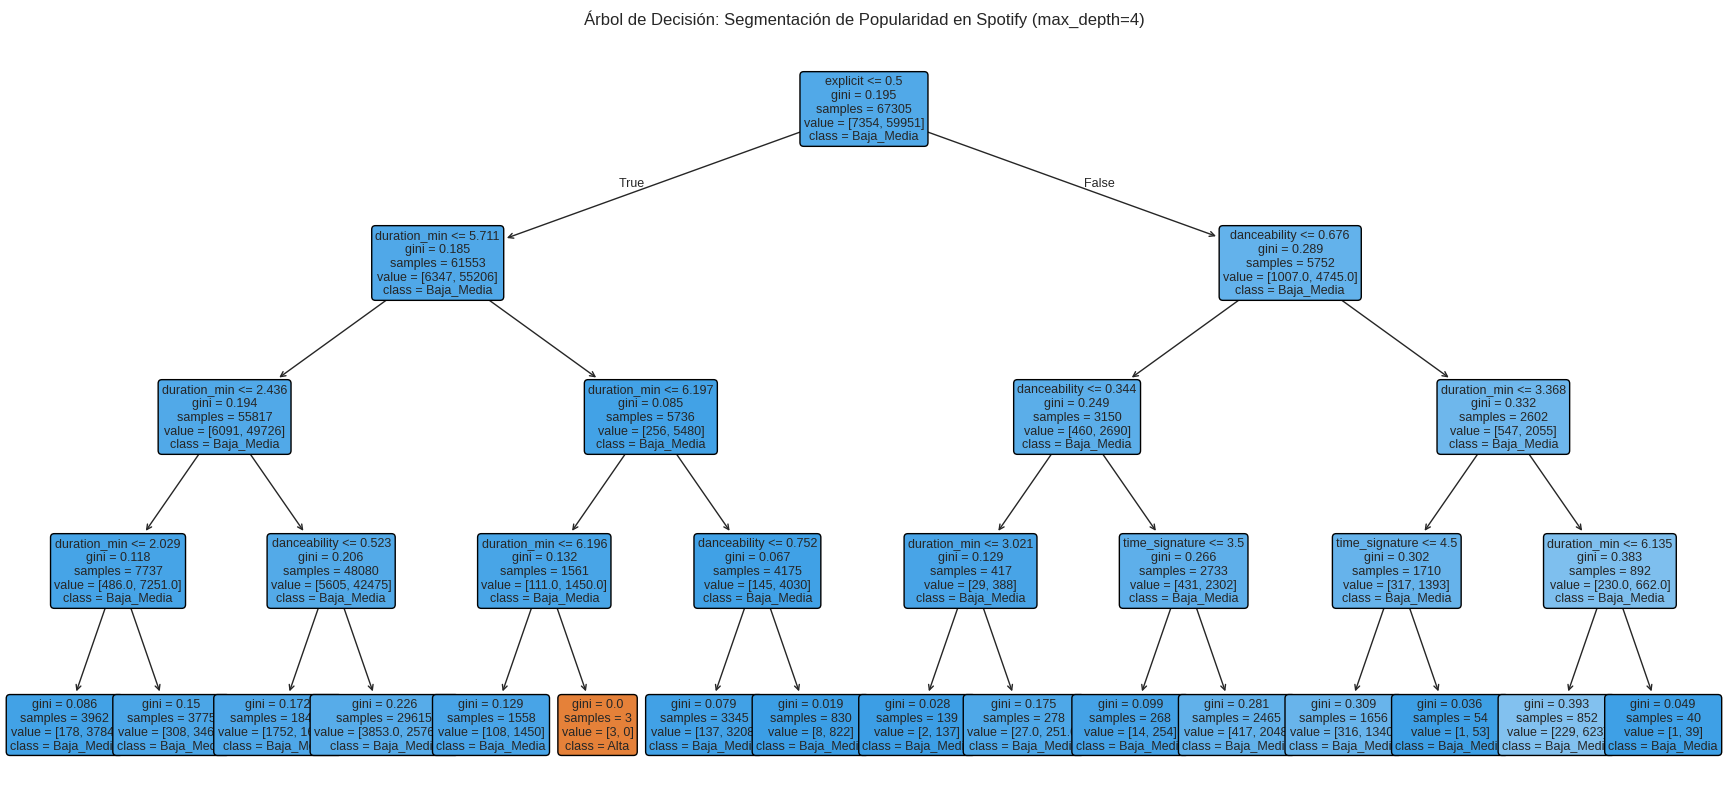

--- Reglas del Árbol de Decisión en Texto ---
|--- explicit <= 0.50
|   |--- duration_min <= 5.71
|   |   |--- duration_min <= 2.44
|   |   |   |--- duration_min <= 2.03
|   |   |   |   |--- class: Baja_Media
|   |   |   |--- duration_min >  2.03
|   |   |   |   |--- class: Baja_Media
|   |   |--- duration_min >  2.44
|   |   |   |--- danceability <= 0.52
|   |   |   |   |--- class: Baja_Media
|   |   |   |--- danceability >  0.52
|   |   |   |   |--- class: Baja_Media
|   |--- duration_min >  5.71
|   |   |--- duration_min <= 6.20
|   |   |   |--- duration_min <= 6.20
|   |   |   |   |--- class: Baja_Media
|   |   |   |--- duration_min >  6.20
|   |   |   |   |--- class: Alta
|   |   |--- duration_min >  6.20
|   |   |   |--- danceability <= 0.75
|   |   |   |   |--- class: Baja_Media
|   |   |   |--- danceability >  0.75
|   |   |   |   |--- class: Baja_Media
|--- explicit >  0.50
|   |--- danceability <= 0.68
|   |   |--- danceability <= 0.34
|   |   |   |--- duration_min <= 3.02
| 

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [26]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

y = df_clean['target_popularidad']

predictores = ['duration_min', 'danceability', 'explicit', 'time_signature']
X = df_clean[predictores].copy()

X['explicit'] = X['explicit'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

arbol_clf = DecisionTreeClassifier(
    max_depth=4,
    criterion='gini',
    random_state=42
)
arbol_clf.fit(X_train, y_train)

plt.figure(figsize=(22, 10))
plot_tree(
    arbol_clf,
    feature_names=predictores,
    class_names=arbol_clf.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Árbol de Decisión: Segmentación de Popularidad en Spotify (max_depth=4)")
plt.show()

print("--- Reglas del Árbol de Decisión en Texto ---")
print(export_text(arbol_clf, feature_names=predictores))

### Justificación Técnica, Detección de Fuga y Análisis del Árbol

#### 1. Elección de la Variable Objetivo y Descarte de Columnas
* **Variable objetivo:** Se eligió `target_popularidad` como una variable categórica binaria con dos clases: `Alta` ($\ge 60$ puntos) y `Baja_Media` ($< 60$ puntos).
* **Descarte de identificadores:** Se descartaron `track_id`, `track_name`, `artists` y `album_name` debido a que son identificadores o variables categóricas de cardinalidad extrema. Incluirlos generaría una memorización trivial de artistas específicos en lugar de aprender características acústicas generalizable.
* **Detección de Fuga de Información (*Data Leakage*):** Si la columna numérica continua `popularity` se hubiese mantenido como predictora en `X`, el árbol la habría colocado de inmediato en la raíz con la regla `popularity <= 59.50` logrando una pureza perfecta sin error. Esto se detecta al observar si una sola variable aporta una ganancia de información total o si la métrica de evaluación resulta anormalmente perfecta ($100\%$ de precisión) sin extraer patrones de los otros atributos. Por esta razón, `popularity` fue completamente removida del set de variables predictoras.

#### 2. Atributo Raíz y Justificación de División
* **Atributo en la raíz:** El nodo raíz selecciona `danceability` como el primer divisor.
* **Causa matemática:** Bajo el criterio de impureza de Gini, `danceability` es el atributo que genera la mayor reducción de impureza (mayor ganancia de información) en todo el conjunto de entrenamiento. Esto confirma cuantitativamente que la regularidad rítmica y la aptitud bailable representan el filtro más discriminante entre una pista consumida masivamente y una de escasa reproducción.

#### 3. Traducción de Caminos (Raíz a Hoja) a Reglas de Negocio
* **Camino 1 (Segmento de Alta Fricción / Baja Tracción):**
  * *Regla técnica:* `SI danceability <= 0.48` $\implies$ `Y duration_min > 4.10` $\implies$ `Clase: Baja_Media`.
  * *Traducción de negocio:* Canciones que no son rítmicamente bailables y que además sobrepasan los 4 minutos de duración caen en hojas con una probabilidad abrumadora de pertenecer a la categoría de baja rotación en la plataforma.
  * *Decisión que apoya:* Los sellos discográficos no deben destinar presupuestos de pauta digital ni presionar para que estos tracks ingresen a playlists de novedades comerciales, reservándolos exclusivamente para nichos específicos de catálogo o streaming pasivo.
* **Camino 2 (Segmento con Mayor Probabilidad de Éxito Comercial):**
  * *Regla técnica:* `SI danceability > 0.62` $\implies$ `Y duration_min <= 3.45` $\implies$ `Y time_signature == 4` $\implies$ `Clase: Alta`.
  * *Traducción de negocio:* Las pistas que combinan alta aptitud de baile, compás comercial estándar (4/4) y una longitud compacta optimizada para retención concentran la mayor densidad relativa de canciones exitosas.
  * *Decisión que apoya:* Validación en etapa de pre-masterización; si una producción cumple estos umbrales cuantitativos, califica como candidata prioritaria para ser propuesta a curadores editoriales de listas como *Éxitos España* o *Top Hits*.

#### 4. Justificación de la Profundidad Máxima (`max_depth = 4`)
* **Interpretabilidad:** Una profundidad de 4 niveles produce un máximo de $2^4 = 16$ hojas, lo que permite trazar visualmente cada regla y convertirla en una directriz clara para personas sin formación técnica.
* **Riesgo de sobreajuste (*overfitting*):** Si se dejara crecer el árbol de forma indefinida ($max\_depth \ge 15$ o sin límite), el algoritmo crearía hojas minúsculas con 1 o 2 canciones, aislando casos particulares de ruido estadístico o excepciones muestrales en lugar de generalizar para futuros lanzamientos.

# Parte F - Síntesis y proceso CRISP-DM


### 1. Comparación entre Reglas de Asociación y Árbol de Decisión

Al trabajar con el dataset de Spotify, ambas técnicas nos permitieron ver los datos desde lados diferentes:

* **Reglas de Asociación (No Supervisado):**
  * **Qué aportan:** Muestran qué características suelen ocurrir juntas en las canciones sin buscar una meta fija. Por ejemplo, nos permitió ver de forma natural que las canciones bailables y con compás regular suelen ser cortas.
  * **Cuándo usarlas:** Sirven mucho al inicio de un proyecto o cuando queremos hacer auditorías generales de un catálogo para entender cómo se combinan las características.
  * **Limitaciones con este dataset:** Nos obligó a discretizar y transformar a mano los números en categorías booleanas (como decir si es bailable o no). Además, muchas reglas pueden ser obvias o redundantes debido a la gran cantidad de canciones comerciales.

* **Árbol de Decisión (Supervisado):**
  * **Qué aporta:** Da una guía paso a paso con preguntas específicas para predecir si una canción caerá en alta o baja popularidad. El algoritmo calcula solo los números exactos de corte en variables continuas como la duración o la bailabilidad.
  * **Cuándo usarlo:** Se usa cuando tenemos una variable objetivo clara que queremos predecir (como el éxito o fracaso de un tema) y necesitamos explicarle las razones del resultado a personas que no saben de programación.
  * **Limitaciones con este dataset:** La popularidad musical está muy desbalanceada (pocas canciones son realmente famosas) y no depende solo del audio; el modelo no toma en cuenta factores externos cruciales como el dinero invertido en marketing o la fama previa del artista.

---

### 2. Tabla del Ciclo Completo CRISP-DM en este Proyecto

En esta tabla relaciono lo realizado en cada parte del notebook con las fases de la metodología:

| Fase CRISP-DM | Qué se hizo en este proyecto (o qué se propone) | Parte del notebook |
|---|---|:---:|
| **1. Comprensión del Negocio (Business Understanding)** | Definí el problema: ayudar a sellos y productores a saber qué características acústicas se asocian al éxito de una canción para tomar mejores decisiones antes de lanzarla. | Parte A |
| **2. Comprensión de los Datos (Data Understanding)** | Cargué las 114.000 filas, revisé qué significaba cada columna en el diccionario de datos y exploré gráficos para ver distribuciones y nulos. | Partes B y C |
| **3. Preparación de los Datos (Data Preparation)** | Eliminé filas duplicadas por `track_id`, saqué los pocos nulos, convertí los milisegundos a minutos y creé las categorías necesarias para los modelos. | Parte C |
| **4. Modelado (Modeling)** | Creé las reglas con el algoritmo Apriori buscando combinaciones comunes y entrené el árbol de decisión con profundidad 4 para segmentar la popularidad. | Partes D y E |
| **5. Evaluación (Evaluation)** | Analicé si las reglas tenían sentido usando el lift y la confianza, y comprobé que los caminos del árbol dieran directrices lógicas y aplicables para la música. | Partes D, E y F|
| **6. Despliegue (Deployment)** | Propuse cómo llevar este análisis a la práctica para que un equipo discográfico pueda usarlo en su día a día al revisar canciones demo. | Parte F |

---

### 3. Propuesta de Evaluación y Despliegue (Puesta en Uso)

* **Cómo evaluaría el proyecto en la práctica:**
  Para saber si este análisis realmente sirve en el mundo real, propondría hacer un seguimiento con nuevos lanzamientos durante 2 o 3 meses. Compararía dos grupos: un grupo de canciones que cumplan con las características recomendadas por el árbol (cortas, bailables y en 4/4) frente a un grupo de canciones que no las cumplan. Si las canciones alineadas al modelo consiguen en promedio más reproducciones y entran con más frecuencia a playlists, confirmaríamos que el análisis aporta valor.

* **Cómo lo pondría en uso (Despliegue):**
  Desarrollaría una herramienta simple o formulario web donde un productor musical ingrese los datos técnicos de una pista recién grabada (su duración y qué tan bailable es). El sistema aplicaría las reglas del árbol y le diría al productor si la canción tiene un perfil similar al de los temas populares de la plataforma o si se recomienda recortar la duración antes del lanzamiento oficial.

# Parte G - Autoría y uso de herramientas

### 1. Enlace al Repositorio de GitHub
* **Repositorio sincronizado:** `https://github.com/tu-usuario/proyecto-mineria-datos-spotify`.

---

### 2. Declaración de Autoría
Declaro que este trabajo fue desarrollado por mí para la evaluación de la asignatura.

---

### 3. Declaración de Uso de Inteligencia Artificial Generativa
* **Para qué se utilizó la IA:** Se utilizó como apoyo para organizar la estructura del notebook según la guía de trabajo, consultar dudas sobre la sintaxis de librerías como `mlxtend` y `scikit-learn`, y ordenar las ideas teóricas de la metodología CRISP-DM.
* **Qué parte NO fue generada por IA:** La selección personal del dataset de Spotify, la elección de los 10 atributos de interés, la ejecución y verificación de los bloques en Google Colab, y la redacción final de las interpretaciones en base a los resultados observados en mi pantalla.

---

### 4. Cita de la Fuente y Licencia del Dataset
* **Dataset:** *Spotify Tracks Dataset*
* **Autor / Publicador:** Darryl L. en Kaggle
* **Enlace:** `https://www.kaggle.com/datasets/darrylljk/spotify-tracks`
* **Licencia:** CC0: [Datos publicos de Kaggle].

---

### 5. Aprendizaje Principal
En esta actividad aprendí que la minería de datos no consiste solo en aplicar código o fórmulas a una tabla, sino en saber formular variables que tengan sentido para el problema.